In [1]:
import re, os
import burnman
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy import constants as const
from matplotlib.patches import Patch
from burnman import minerals, Composite,Composition, Layer, Planet, Mineral
from burnman.tools.chemistry import formula_mass

# Librería IAPWS para propiedades del agua
from iapws import IAPWS95
from iapws.iapws97 import IAPWS97
from iapws.iapws08 import _Tf, _Tb, _Triple
from iapws._iapws import _Sublimation_Pressure, _Melting_Pressure

In [2]:
%load_ext autoreload
%autoreload 2

import geotherm_calculator as gc
import habitability_calculator as hc
import planetary_grid_reader as pgr

In [3]:
Gpa = 1e9
Mpa = 1e6
km = 1e3
to = 1.386e9 #Terrestrial Oceans volume in km3
G = const.G.value # Gravitational constant (m3 kg-1 s-2)
g_earth = const.g0.value # Surface gravity Earth (m s-2)

Me = const.M_earth.value # Earth mass (kg) 
Re = const.R_earth.value # Earth radius (m) 

Lsun = const.L_sun.value # Solar luminosity (W)
au = const.au.value # Astronomical Unit (m)

hc_earth = 35  #km
hr_earth = np.array([0.25, 0.35])*hc_earth 


In [4]:
comp_earth = gc.COMPOSITION_DEFAULT #Hasterok & Chapman


In [5]:
def layer_comp(f_felsic_capa, hidr_capa, X_Mg, X_Fe, es_manto=False):
    """
    Calcula la composición mineralógica normalizada para una sola capa geológica.
    
    Parámetros:
    ----------
    f_felsic_capa : float (Fracción félsica específica de esta capa)
    hidr_capa     : float (Nivel de hidratación específico de esta capa)
    X_Mg          : float (Fracción molar de Magnesio)
    X_Fe          : float (Fracción molar de Hierro)
    es_manto      : bool  (Fuerza una composición de peridotita/granates si es True)
    """
    
    # 1. Base estructural
    if es_manto:
        Quartz_base = 0.0
        Orthoclase_base = 0.0
        Albite_base = 0.0
        Anorthite_base = 0.0
        piroxeno_total = 35.0
        olivino_total = 60.0
    else:
        # Composición basada en la fracción félsica
        Quartz_base     = 30.0 * f_felsic_capa
        Orthoclase_base = 15.0 * f_felsic_capa
        Albite_base     = 20.0 * f_felsic_capa + 10.0 * (1 - f_felsic_capa)
        Anorthite_base  = 10.0 * f_felsic_capa + 25.0 * (1 - f_felsic_capa)
        piroxeno_total  = 40.0 * (1 - f_felsic_capa)
        olivino_total   = 20.0 * (1 - f_felsic_capa)

    # 2. Partición Fe/Mg en los minerales ferromagnesianos
    Forsterite = olivino_total * X_Mg
    Fayalite   = olivino_total * X_Fe

    px_ortho = piroxeno_total * 0.7
    px_clino = piroxeno_total * 0.3
    Enstatite    = px_ortho * X_Mg
    Ferrosillite = px_ortho * X_Fe
    Diopside     = px_clino * X_Mg
    Hedenbergite = px_clino * X_Fe

    # 3. Hidratación
    Hornblende = 0.0
    Phlogopite = 0.0

    if hidr_capa > 0 and not es_manto:
        transferencia = hidr_capa * 0.4
        px_total = Enstatite + Ferrosillite + Diopside + Hedenbergite
        delta_px = px_total * transferencia

        if px_total > 0:
            factor = (px_total - delta_px) / px_total
            Enstatite    *= factor
            Ferrosillite *= factor
            Diopside     *= factor
            Hedenbergite *= factor

        Hornblende += delta_px

        delta_an = Anorthite_base * (transferencia * 0.3)
        Anorthite_base -= delta_an
        Hornblende += delta_an

        delta_k = Orthoclase_base * hidr_capa * 0.5
        Orthoclase_base -= delta_k
        Phlogopite += delta_k

    # 4. Ensamblar diccionario base
    comp_bruta = {
        "Quartz": Quartz_base,
        "Orthoclase": Orthoclase_base,
        "Albite": Albite_base,
        "Anorthite": Anorthite_base,
        "Forsterite": Forsterite,
        "Fayalite": Fayalite,
        "Enstatite": Enstatite,
        "Ferrosillite": Ferrosillite,
        "Diopside": Diopside,
        "Hedenbergite": Hedenbergite,
        "Hornblende": Hornblende,
        "Phlogopite": Phlogopite
    }
    
    # Añadir granates si es el manto
    if es_manto:
        comp_bruta["Pyrope"] = 5.0 * X_Mg
        comp_bruta["Almandine"] = 5.0 * X_Fe

    # 5. Limpieza y Normalización
    comp_bruta = {k: max(0, v) for k, v in comp_bruta.items()}
    total = sum(comp_bruta.values())
    
    if total == 0:
        raise ValueError("Composición degenerada en la capa calculada.")

    # Retornar solo los minerales presentes (> 0) normalizados al 100%
    return {mineral: (val / total * 100) for mineral, val in comp_bruta.items() if val > 0}


def crust_comp(f_felsic=0.5, Fe_Mg=0.1, hidratacion=0.0):
    """
    Genera un diccionario completo (upper, middle, lower, mantle) 
    parametrizado según la geoquímica general del exoplaneta.

    Parámetros:
    ----------
    f_felsic : float (Fracción félsica en la superficie)
    Fe_Mg : float (Ratio molar Fe/Mg global del planeta)
    hidratacion : float (Grado de hidratación en la superficie)
    """

    # La partición de Fe/Mg es global para todo el planeta
    X_Fe = Fe_Mg / (1.0 + Fe_Mg)
    X_Mg = 1.0 - X_Fe

    # 1. UPPER CRUST: Usa los parámetros superficiales intactos
    upper = layer_comp(f_felsic, hidratacion, X_Mg, X_Fe)
    
    # 2. MIDDLE CRUST: Transición (mitad de influencia félsica y de agua)
    middle = layer_comp(f_felsic * 0.5, hidratacion * 0.5, X_Mg, X_Fe)
    
    # 3. LOWER CRUST: Casi completamente máfica (Gabroide) y muy seca
    lower = layer_comp(f_felsic * 0.1, hidratacion * 0.1, X_Mg, X_Fe)
    
    # 4. MANTLE: Estrictamente ultramáfico (Peridotita), seco, sin feldespatos
    mantle = layer_comp(0.0, 0.0, X_Mg, X_Fe, es_manto=True)

    # Retornar el diccionario estructurado
    return {
        "upper": upper,
        "middle": middle,
        "lower": lower,
        "mantle": mantle
    }

In [24]:
mineral_objects = gc.get_mineral_objects()

f_felsic_vals = np.linspace(0.0, 1.0, 11)  # [0.0, 0.1, 0.2, ..., 1.0]
Fe_Mg_vals = np.linspace(0.0, 0.5, 11)     # [0.0, 0.05, 0.10, ..., 0.50]

# Mantenemos 2 paneles para poder compararlos lado a lado
hidratacion_vals = np.array([0.0, 0.30])

In [32]:
geos = np.zeros((len(f_felsic_vals), len(Fe_Mg_vals), len(hidratacion_vals)), dtype=object)

for i in range(len(f_felsic_vals)):
    for j in range(len(Fe_Mg_vals)):
        for k in range(len(hidratacion_vals)):
            comp = crust_comp(f_felsic=f_felsic_vals[i], Fe_Mg=Fe_Mg_vals[j], hidratacion=hidratacion_vals[k])
            print(f"f_felsic={f_felsic_vals[i]:.2f}, Fe/Mg={Fe_Mg_vals[j]:.2f}, hidratacion={hidratacion_vals[k]:.2f}")
            
            rock = gc.prepare_rocks_dict(composition=comp, 
                           mineral_objects=mineral_objects)
            
            geo = gc.calculate_geotherm(rocks = rock,
                                        composition=comp,
                                        q_s = 65e-3,
                                        z_max=15*km,
                                        dz = 100,
                                        R_planet=Re,
                                        M_total=Me,
                                        boundaries = gc.scale_layer_boundaries(Re),
                                        phi = 0.01                                         
                                        )
            geos[i, j, k] = geo
            
            
            

f_felsic=0.00, Fe/Mg=0.00, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.00, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.05, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.05, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.10, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.10, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.15, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.15, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.20, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.20, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.25, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.25, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.30, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.30, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.35, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.35, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.40, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.40, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.45, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.45, hidratacion=0.30
f_felsic=0.00, Fe/Mg=0.50, hidratacion=0.00
f_felsic=0.00, Fe/Mg=0.50, hidratacion=0.30
f_felsic=0.10, Fe/Mg=0.00, hidra

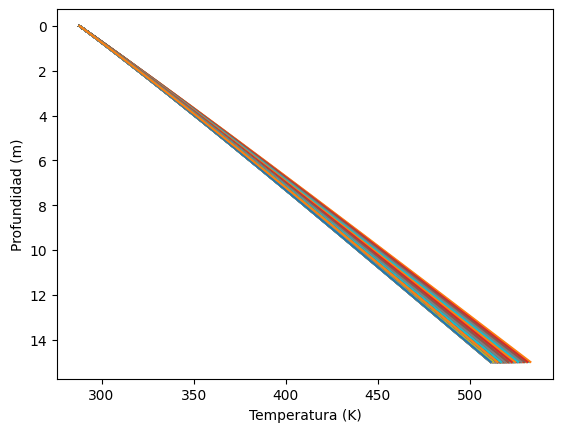

In [33]:
#grafica de todas las geotermas en geos
for i in range(geos.shape[0]):
    for j in range(geos.shape[1]):
        for k in range(geos.shape[2]):
            geo = geos[i, j, k]
            plt.plot(geo['T_K'], geo['depth_m']/km, label=f"f_felsic={f_felsic_vals[i]:.2f}, Fe/Mg={Fe_Mg_vals[j]:.2f}, hidratacion={hidratacion_vals[k]:.2f}")
            plt.xlabel("Temperatura (K)")
            plt.ylabel("Profundidad (m)")

plt.gca().invert_yaxis()

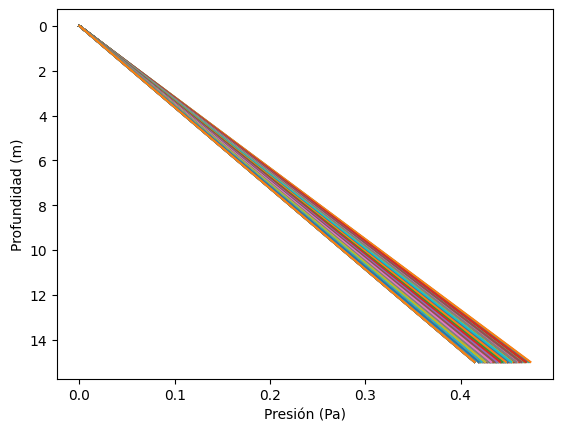

In [34]:
for i in range(geos.shape[0]):
    for j in range(geos.shape[1]):
        for k in range(geos.shape[2]):
            geo = geos[i, j, k]
            plt.plot(geo['P_Pa']/1e9, geo['depth_m']/km, label=f"f_felsic={f_felsic_vals[i]:.2f}, Fe/Mg={Fe_Mg_vals[j]:.2f}, hidratacion={hidratacion_vals[k]:.2f}")
            plt.xlabel("Presión (Pa)")
            plt.ylabel("Profundidad (m)")

plt.gca().invert_yaxis()

In [35]:
#para cada geo calcular la capa habitable y aguable
mapa_seco = np.zeros((len(f_felsic_vals), len(Fe_Mg_vals)))
mapa_hidr = np.zeros((len(f_felsic_vals), len(Fe_Mg_vals)))

for i in range(geos.shape[0]):
    for j in range(geos.shape[1]):
        for k in range(geos.shape[2]):
            geo = geos[i, j, k]
            liq = hc.find_liquid_zone(geo)
            hab = hc.find_habitable_zone(liq['indices'], geo, P_bio_max=200e6, T_bio_max=423.0)
            
            # Calcular espesor en km
            if len(hab['indices']) > 0:
                thick_hab = (hab['habitable_zone'][-1] - hab['habitable_zone'][0]) / 1000.0
            else:
                thick_hab = 0.0

            # Asignar el espesor a la matriz correspondiente según la hidratación
            if hidratacion_vals[k] == 0.0:
                mapa_seco[i, j] = thick_hab
            else:
                mapa_hidr[i, j] = thick_hab

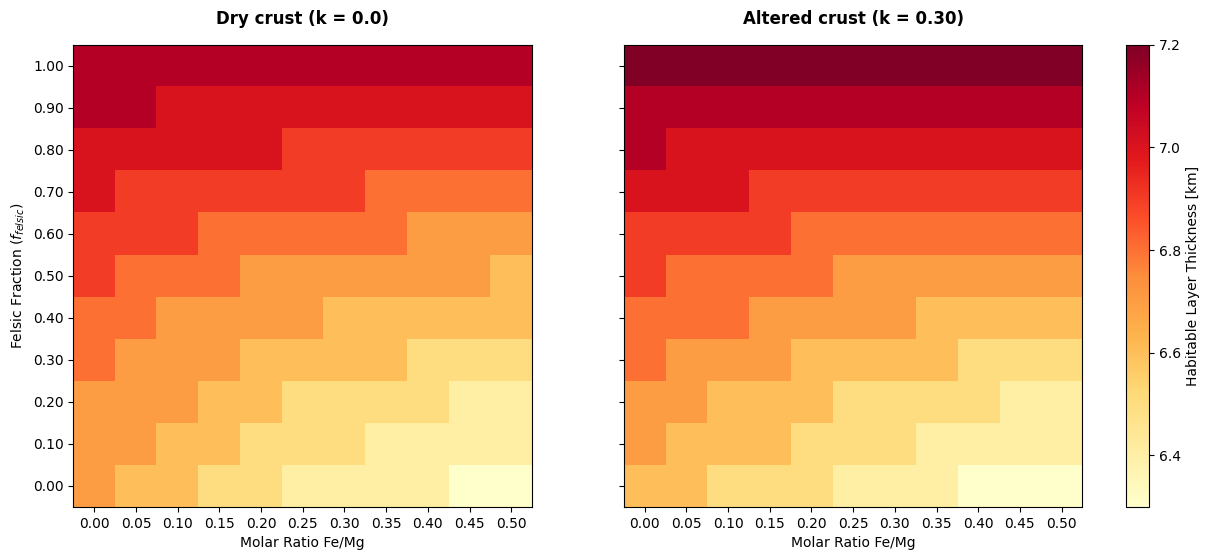

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Definir escala de color global (para que el rojo signifique lo mismo en ambos)
vmin = min(np.min(mapa_seco), np.min(mapa_hidr))
vmax = max(np.max(mapa_seco), np.max(mapa_hidr))
cmap = 'YlOrRd' # De amarillo (menor) a rojo (mayor)

# Función auxiliar para dibujar y anotar cada subgráfico
def plot_heatmap(ax, data, title):
    # origin='lower' asegura que el índice 0 (f_felsic=0.20) quede en la parte inferior del eje Y
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    
    # Configurar los "ticks" (las marcas en los ejes)
    ax.set_xticks(np.arange(len(Fe_Mg_vals)))
    ax.set_yticks(np.arange(len(f_felsic_vals)))
    
    # Poner las etiquetas reales de tus variables
    ax.set_xticklabels([f"{v:.2f}" for v in Fe_Mg_vals])
    ax.set_yticklabels([f"{v:.2f}" for v in f_felsic_vals])
    
    # Títulos y etiquetas
    ax.set_title(title, fontweight='bold', pad=15)
    ax.set_xlabel('Molar Ratio Fe/Mg')
    
    # Bucle manual para escribir los números dentro de los cuadros (lo que hacía annot=True)
    for i in range(len(f_felsic_vals)):
        for j in range(len(Fe_Mg_vals)):
            # Truco visual: si el color de fondo es muy oscuro (valor alto), poner texto blanco
            val_norm = (data[i, j] - vmin) / (vmax - vmin) if vmax != vmin else 0
            text_color = "white" if val_norm > 0.6 else "black"
            
            #ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", color=text_color, fontweight='bold')
    return im

# Dibujar panel izquierdo
im1 = plot_heatmap(axes[0], mapa_seco, 'Dry crust (k = 0.0)')
axes[0].set_ylabel(r'Felsic Fraction ($f_{felsic}$)')

# Dibujar panel derecho
im2 = plot_heatmap(axes[1], mapa_hidr, 'Altered crust (k = 0.30)')

# Agregar una única barra de color compartida para toda la figura
cbar = fig.colorbar(im2, ax=axes, fraction=0.03, pad=0.04)
cbar.set_label('Habitable Layer Thickness [km]')

plt.show()